### Análisis e Imputación de Datos Faltantes
1. Importación de librerías

Se importan las librerías necesarias para el análisis y manipulación de datos.

In [66]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

2. Carga del dataset

Se carga el archivo CSV que contiene los registros de accidentes.

In [67]:
file_name = "dataset_accidentes_500.csv"

df_accidentes = pd.read_csv(
    file_name,
    sep=",",
    header=0,
    encoding="utf-8",
)

df_accidentes.head(10)

,id,fecha,ciudad,tipo_accidente,heridos,fallecidos,daños_materiales_usd
0,1,2023-01-01,Arequipa,Atropello,NaN,0.0,3566.0
1,2,2023-01-02,Trujillo,Caída,0.0,1.0,3181.0
2,3,2023-01-03,Cusco,Caída,3.0,0.0,729.0
3,4,2023-01-04,Trujillo,Choque,2.0,0.0,369.0
4,5,2023-01-05,Trujillo,Atropello,1.0,NaN,5824.0
5,6,2023-01-06,Ayacucho,Choque,NaN,NaN,NaN
6,7,2023-01-07,Cusco,Volcadura,4.0,0.0,3532.0
7,8,2023-01-08,Cusco,Volcadura,3.0,2.0,9572.0
8,9,2023-01-09,Cusco,Choque,NaN,NaN,NaN
9,10,2023-01-10,Trujillo,Caída,1.0,1.0,5995.0


3. Información general del dataset

Se utiliza .info() para conocer la estructura del dataframe, tipos de datos y detectar valores nulos.

In [68]:
df_accidentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    500 non-null    int64  
 1   fecha                 500 non-null    str    
 2   ciudad                500 non-null    str    
 3   tipo_accidente        500 non-null    str    
 4   heridos               375 non-null    float64
 5   fallecidos            375 non-null    float64
 6   daños_materiales_usd  375 non-null    float64
dtypes: float64(3), int64(1), str(3)
memory usage: 27.5 KB


4. Identificación de datos faltantes

Se analizan los valores nulos utilizando diferentes métodos:

- isna() → detecta valores nulos
- sum() → cantidad total de nulos por columna
- mean() * 100 → porcentaje de nulos

También se usa .describe() para entender la distribución de los datos.

In [69]:
df_accidentes.describe()
#df_accidentes[['heridos','fallecidos','daños_materiales_usd']].isna().corr()

,id,heridos,fallecidos,daños_materiales_usd
count,500.000000,375.000000,375.000000,375.000000
mean,250.500000,1.968000,0.973333,5279.466667
std,144.481833,1.434502,0.807275,2882.234746
min,1.000000,0.000000,0.000000,111.000000
25%,125.750000,1.000000,0.000000,2969.000000
50%,250.500000,2.000000,1.000000,5399.000000
75%,375.250000,3.000000,2.000000,7509.000000
max,500.000000,4.000000,2.000000,9984.000000


5. Visualización de valores nulos

Se genera una gráfica de barras para observar el porcentaje de datos faltantes por columna.

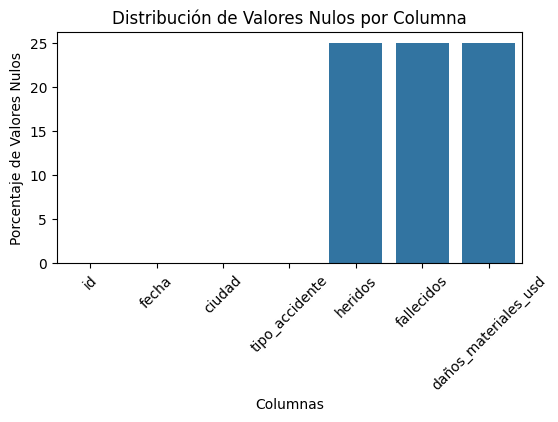

In [70]:

# Calcula el porcentaje de valores nulos por columna
null_counts = df_accidentes.isna().mean() * 100

# Crea la gráfica de barras para visualizar la distribución de valores nulos por columna
plt.figure(figsize=(6, 3))
sns.barplot(x=null_counts.index, y=null_counts.values)
plt.xticks(rotation=45)
plt.ylabel('Porcentaje de Valores Nulos')
plt.title('Distribución de Valores Nulos por Columna')
plt.xlabel('Columnas')

plt.show()


6. Visualización con missingno

Se utiliza la librería missingno para visualizar la distribución de valores nulos de forma gráfica

<Axes: >

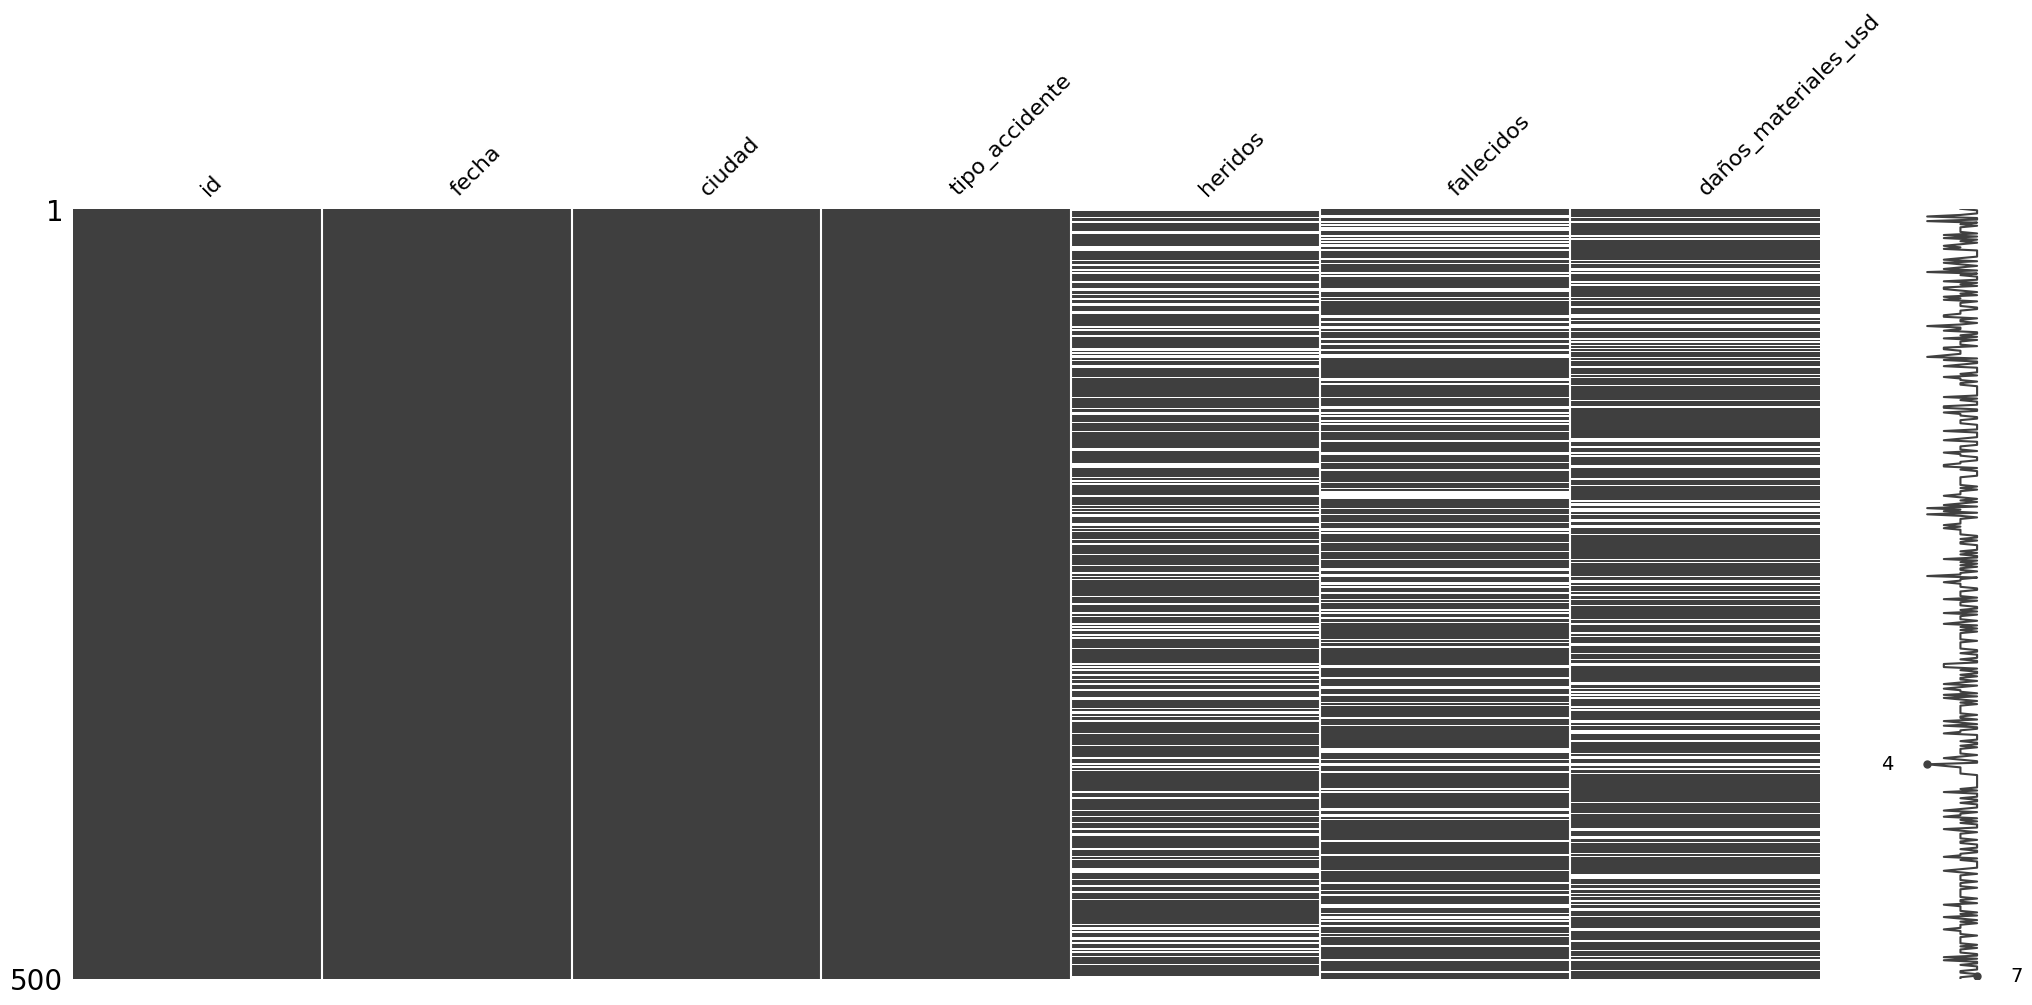

In [71]:
msno.matrix(df_accidentes)

7. Imputación de datos faltantes

Se aplica imputación mediante la mediana en las columnas con valores nulos.
Se elige este método porque representa adecuadamente la tendencia central y es robusto ante posibles valores extremos.

In [72]:
columnas = ["heridos", "fallecidos", "daños_materiales_usd"]

for col in columnas:
    df_accidentes[col] = df_accidentes[col].fillna(df_accidentes[col].median())

df_accidentes.isna().sum()

id                      0
fecha                   0
ciudad                  0
tipo_accidente          0
heridos                 0
fallecidos              0
daños_materiales_usd    0
dtype: int64

8. Verificación final

Se valida que ya no existan valores nulos en las columnas imputadas.

In [74]:
df_accidentes.head(10)

,id,fecha,ciudad,tipo_accidente,heridos,fallecidos,daños_materiales_usd
0,1,2023-01-01,Arequipa,Atropello,2.0,0.0,3566.0
1,2,2023-01-02,Trujillo,Caída,0.0,1.0,3181.0
2,3,2023-01-03,Cusco,Caída,3.0,0.0,729.0
3,4,2023-01-04,Trujillo,Choque,2.0,0.0,369.0
4,5,2023-01-05,Trujillo,Atropello,1.0,1.0,5824.0
5,6,2023-01-06,Ayacucho,Choque,2.0,1.0,5399.0
6,7,2023-01-07,Cusco,Volcadura,4.0,0.0,3532.0
7,8,2023-01-08,Cusco,Volcadura,3.0,2.0,9572.0
8,9,2023-01-09,Cusco,Choque,2.0,1.0,5399.0
9,10,2023-01-10,Trujillo,Caída,1.0,1.0,5995.0


💡 Notas:

Se identificó un 25% de valores nulos en las columnas analizadas.
No se utilizó eliminación de datos para evitar pérdida significativa de información.
La imputación por mediana fue seleccionada tras analizar la distribución de los datos.